# Résultats et Observations

In [52]:
import matplotlib.pyplot as plt

def plot_losses(losses):
    # Création d'une liste d'époques pour l'axe des x
    epochs = range(1, len(losses) + 1)
    
    # Tracer les valeurs de perte en fonction des époques
    plt.plot(epochs, losses, 'b', label='Perte (MSE)')
    plt.title('Évolution de la loss (MSE) pendant l\'entraînement')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

def plot_pred(X, preds):
    for (x, y),pred in zip(X,preds):
        if pred == -1:
            plt.scatter(x, y, color='red')
        else:
            plt.scatter(x, y, color='blue')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Nuage de points avec couleurs de classe')
    plt.legend()
    plt.show()

## Importation de la librairie

In [2]:
import ctypes
import numpy as np
import numpy.ctypeslib

# Chemin vers la librairie Rust compilée
rust_path = "../my_lib/target/release/deps/libmy_lib.so"

# Chargement de la bibliothèque Rust
my_lib = ctypes.cdll.LoadLibrary(rust_path)

############## MLP ##############

# Définition des types d'arguments et de retour pour la fonction create_MyMLP
my_lib.create_MyMLP.argtypes = [ctypes.POINTER(ctypes.c_int32), ctypes.c_int32]
my_lib.create_MyMLP.restype = ctypes.c_void_p

# Définition des types d'arguments et de retour pour la fonction train_MyMLP
my_lib.train_MyMLP.argtypes = [ctypes.c_void_p, 
                               ctypes.POINTER(ctypes.c_double), ctypes.c_int32,  # X
                               ctypes.POINTER(ctypes.c_double), ctypes.c_int32,  # y
                               ctypes.c_int32, ctypes.c_double, ctypes.c_int32, ctypes.c_bool]
my_lib.train_MyMLP.restype = ctypes.POINTER(ctypes.c_double)

# Définition des types d'arguments et de retour pour la fonction predict_MyMLP
my_lib.predict_MyMLP.argtypes = [ctypes.c_void_p, ctypes.c_bool,  # Modèle et type de classification
                                 ctypes.POINTER(ctypes.c_double), ctypes.c_int32, ctypes.c_int32]  # Données d'entrée
my_lib.predict_MyMLP.restype = ctypes.POINTER(ctypes.c_double)


############## LINEAR REGRESSION ##############predictions = predict_MLP(model, X, 1, True)
my_lib.create_MyLinearRegression.argtypes = [ctypes.c_int32, ctypes.c_int32]
my_lib.create_MyLinearRegression.restype = ctypes.c_void_p

my_lib.train_MyLinearRegression.argtypes = [ctypes.c_void_p, 
                                            
                                            ctypes.POINTER(ctypes.c_double),
                                            ctypes.c_int32,
                                            
                                            ctypes.POINTER(ctypes.c_double),
                                            ctypes.c_int32,
                                            
                                            ctypes.c_int32]

my_lib.predict_MyLinearRegression.argtypes = [ctypes.c_void_p, 
                                              ctypes.POINTER(ctypes.c_double),
                                              ctypes.c_int32,
                                              ctypes.c_int32]

my_lib.predict_MyLinearRegression.restype = ctypes.POINTER(ctypes.c_double)

## MLP

In [3]:
def create_MLP(nlp):
    # Conversion de la liste des dimensions des couches en tableau numpy d'entiers 32 bits
    nlp = np.array(nlp, np.int32)
    # Conversion du tableau numpy en un objet ctypes compatible avec la fonction Rust
    c_nlp = np.ctypeslib.as_ctypes(nlp)
    
    # Appel de la fonction Rust create_MyMLP avec les dimensions des couches et leur nombre
    model = my_lib.create_MyMLP(c_nlp, len(nlp))
    return model
    
def train_MLP(model, X, y, epochs, alpha, is_classification):
    # Calcul du nombre d'échantillons
    n_samples = len(X)
    
    # Calcul de la taille de chaque échantillon en termes de colonnes
    X_chunk = len(X[0])
    # Conversion de la liste d'entrées X en un tableau numpy de nombres flottants 64 bits et aplatissement
    X = np.array(X, np.float64).flatten()
    
    # Calcul de la taille de chaque étiquette en termes de colonnes
    y_chunk = len(y[0])
    # Conversion de la liste d'étiquettes y en un tableau numpy de nombres flottants 64 bits et aplatissement
    y = np.array(y, np.float64).flatten()
    
    # Conversion des tableaux numpy en objets ctypes compatibles avec les fonctions Rust
    c_X = np.ctypeslib.as_ctypes(X)
    c_y = np.ctypeslib.as_ctypes(y)
    
    # Appel de la fonction Rust train_MyMLP pour entraîner le modèle
    p_losses = my_lib.train_MyMLP(model,
                       c_X,  # Entrées X
                       X_chunk,  # Taille des échantillons X
                       c_y,  # Labels y
                       y_chunk,  # Taille des échantillons y
                       n_samples,  # Nombre total d'échantillons
                       alpha,  # Taux d'apprentissage
                       epochs,  # Nombre d'époques
                       is_classification)  # Type de tâche (classification ou non)
    
    # Conversion du pointeur ctypes en tableau numpy pour les pertes
    losses = np.ctypeslib.as_array(p_losses, (epochs,))
    return losses

def predict_MLP(model, samples, y_sample_size, is_classification):
    c_samples = np.ctypeslib.as_ctypes(np.array(samples, np.float64).flatten())
    
    # Calcul du nombre d'échantillons
    n_samples = len(samples)
    
    # Taille de chaque échantillon en termes de colonnes
    samples_chunk = len(samples[0])
    
    # Appel de la fonction Rust predict_MyMLP pour prédire les sorties
    p_predictions = my_lib.predict_MyMLP(model,
                     is_classification,  # Type de tâche (classification ou non)
                     c_samples,  # Échantillons
                     samples_chunk,  # Taille des échantillons
                     n_samples)  # Nombre total d'échantillons

    # Conversion du pointeur ctypes en tableau numpy pour les prédictions
    predictions = np.ctypeslib.as_array(p_predictions, (n_samples * y_sample_size,)).reshape(n_samples, y_sample_size)
    
    return predictions

### Test XOR

## Test 1

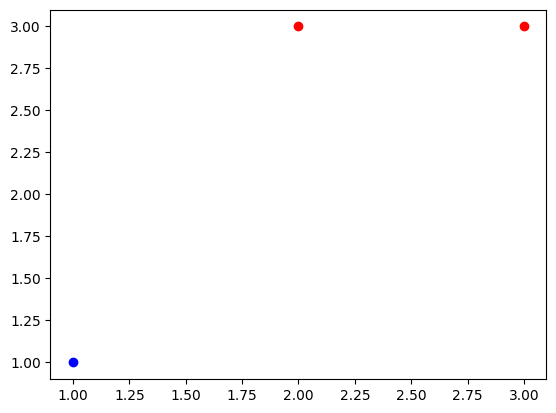

<Figure size 640x480 with 0 Axes>

In [4]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])

Y = np.array([
      1,
      -1,
      -1
])

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

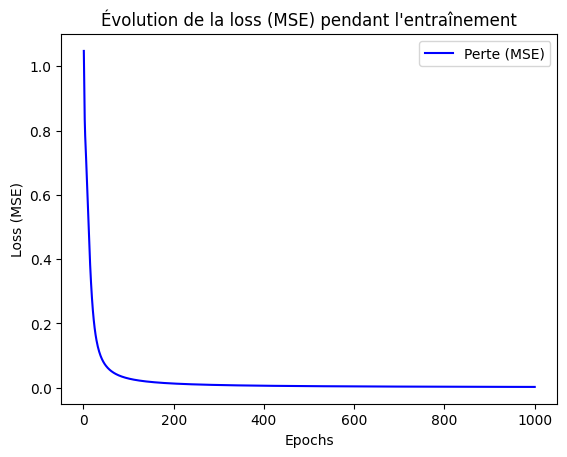

In [5]:
model = create_MLP([2, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 1000, 0.1, True)
plot_losses(losses)

In [8]:
predictions = predict_MLP(model, X, 1, True)
predictions

array([[ 1.],
       [-1.],
       [-1.]])

### Test 2

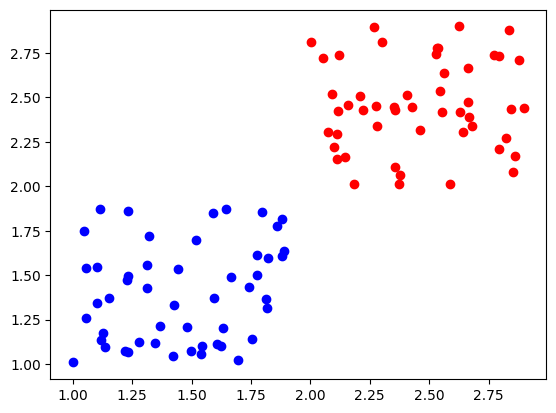

<Figure size 640x480 with 0 Axes>

In [18]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

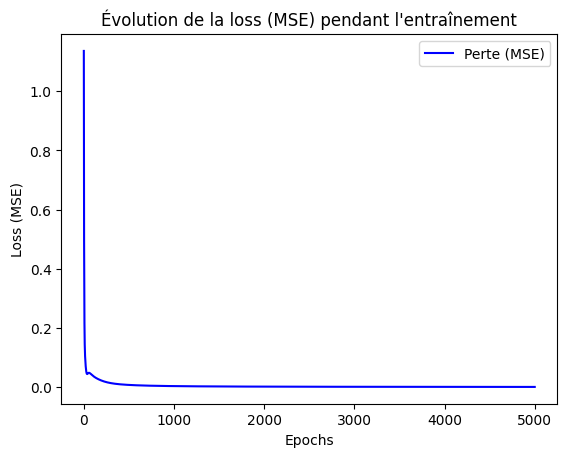

In [10]:
model = create_MLP([2, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 5000, 0.1, True)

plot_losses(losses)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


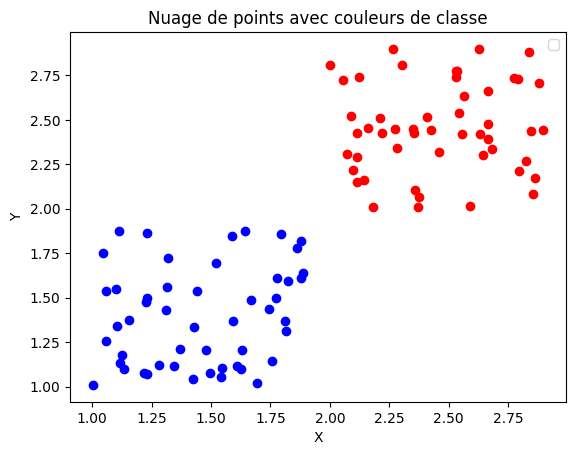

In [51]:
predictions = predict_MLP(model, X, 1, True)
plot_pred(X, predictions)

### Test XOR

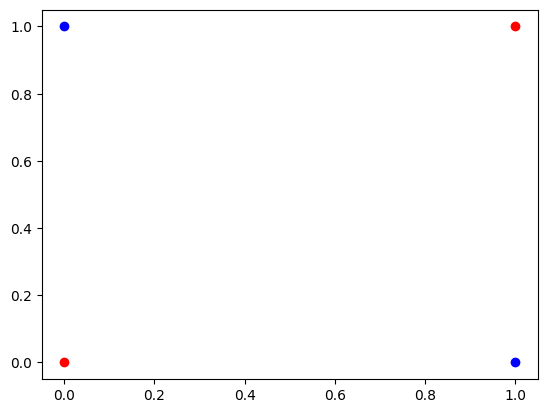

<Figure size 640x480 with 0 Axes>

In [54]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

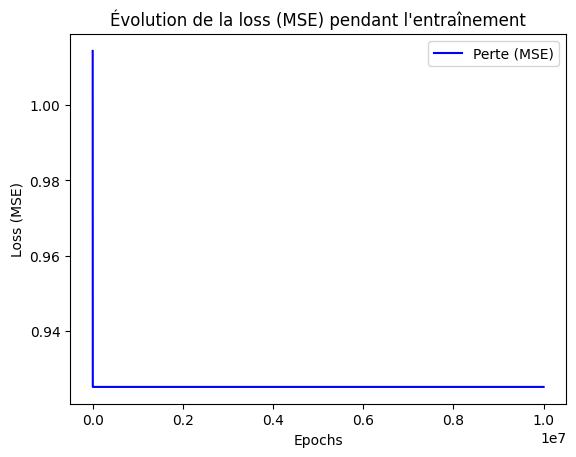

In [55]:
model = create_MLP([2, 2, 1]) 

losses = train_MLP(model, X, Y.reshape(-1, 1), 10_000_000, 0.01, True)

plot_losses(losses)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


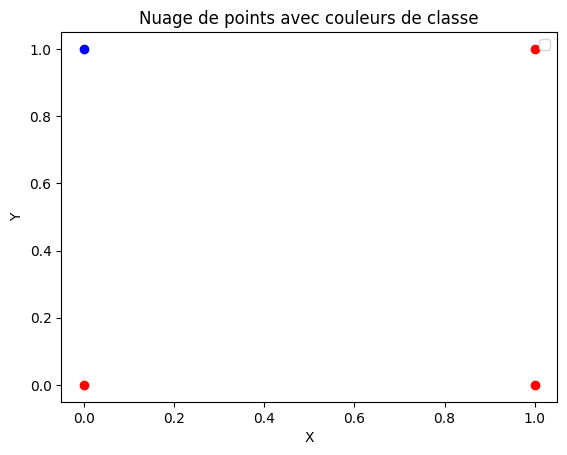

In [57]:
predictions = predict_MLP(model, X, 1, True)
plot_pred(X,predictions)

### Test Cross

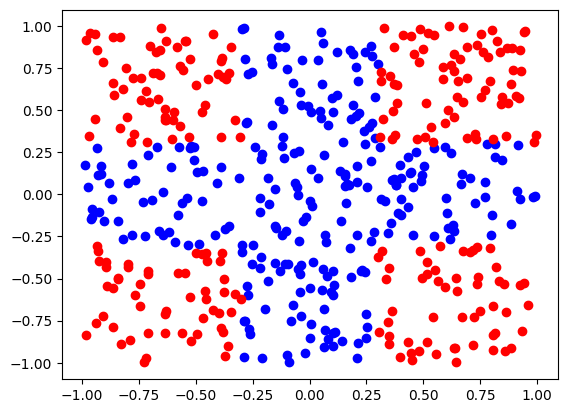

<Figure size 640x480 with 0 Axes>

In [58]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

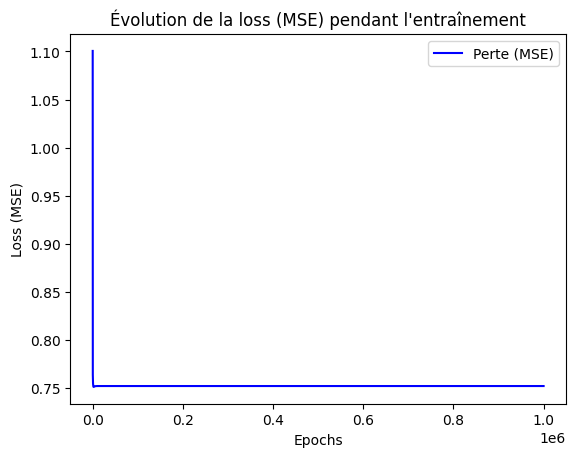

In [63]:
model = create_MLP([2, 4, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 1_000_000, 0.1, True)

plot_losses(losses)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


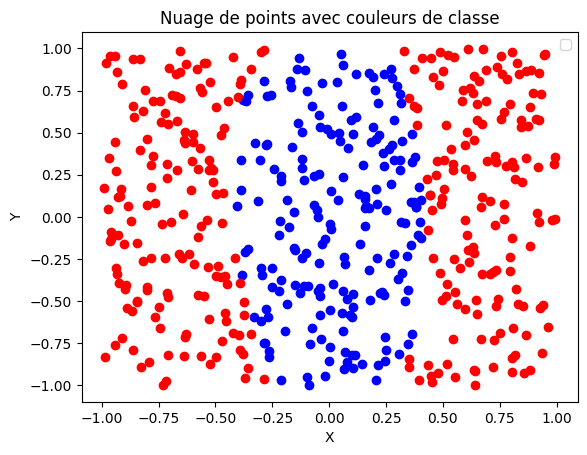

In [64]:
predictions = predict_MLP(model, X, 1, True)
plot_pred(X,predictions)

### Test Multi Linear 3 classes :

In [91]:
def argmax(lst):
    max_index = 0
    max_value = lst[0]
    for i, value in enumerate(lst):
        if value > max_value:
            max_value = value
            max_index = i
    return max_index

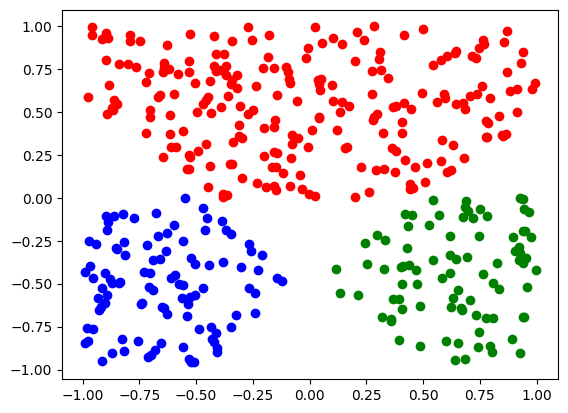

In [98]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()

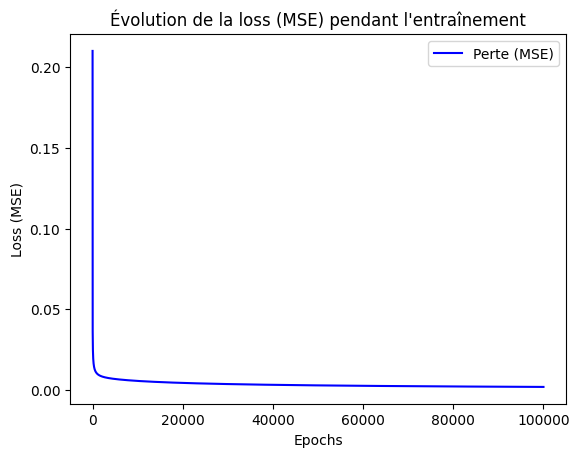

In [101]:
model = create_MLP([2, 3])

losses = train_MLP(model, X, Y, 100_000, 0.1, True)

plot_losses(losses)

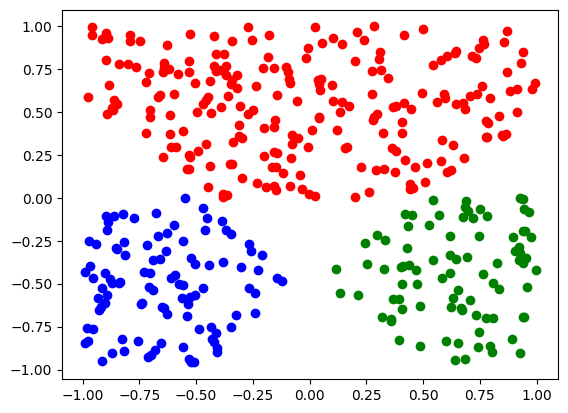

In [107]:
predictions = predict_MLP(model, X, 3, True)

colors = {0:'blue', 1:'red', 2:'green'}
for (x,y),pred in zip(X,predictions):
    plt.scatter(x, y, color=colors[argmax(pred)])

### Multi Cross

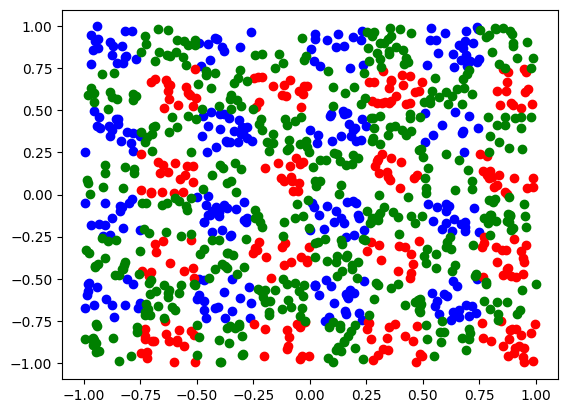

<Figure size 640x480 with 0 Axes>

In [108]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, 0, 0] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [0, 1, 0] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [0, 0, 1] for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

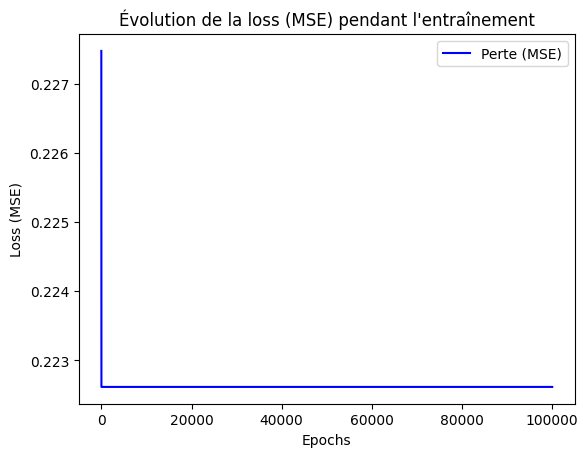

In [116]:
model = create_MLP([2, 3])

losses = train_MLP(model, X, Y, 100_000, 0.1, True)

plot_losses(losses)

In [122]:
predictions

array([[0.37958681, 0.3582798 , 0.38145357],
       [0.24615393, 0.55555178, 0.3120439 ],
       [0.2155075 , 0.45449723, 0.44527082],
       ...,
       [0.27004637, 0.53800399, 0.306356  ],
       [0.21535948, 0.47424952, 0.42528596],
       [0.22538467, 0.52052567, 0.36823209]])

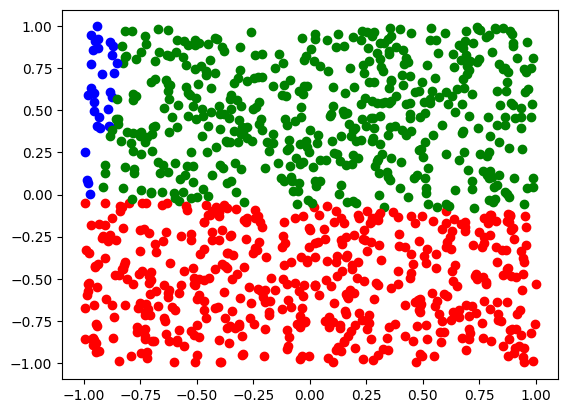

In [121]:
predictions = predict_MLP(model, X, 3, True)
colors = {0:'blue', 1:'red', 2:'green'}
for (x,y),pred in zip(X,predictions):
    plt.scatter(x, y, color=colors[argmax(pred)])

### Régression

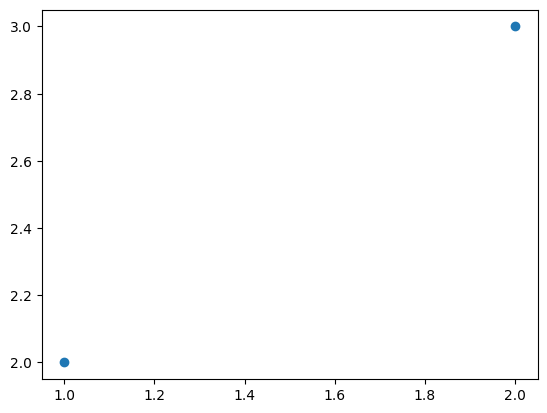

<Figure size 640x480 with 0 Axes>

In [67]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

plt.scatter(X,Y)
plt.show()
plt.clf()

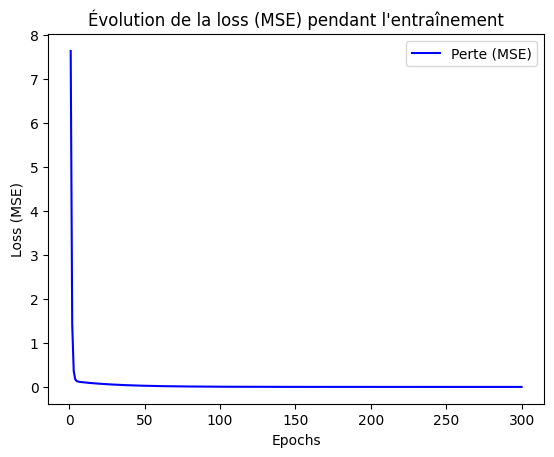

In [68]:
model = create_MLP([1, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 300, 0.1, False)

plot_losses(losses)

In [69]:
predictions = predict_MLP(model, X, 1, False)
predictions

array([[1.9972577],
       [3.0008514]])

### Non Linear Simple 2D :

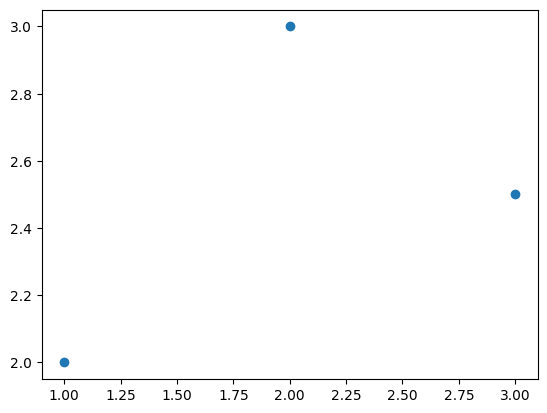

<Figure size 640x480 with 0 Axes>

In [70]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

plt.scatter(X,Y)
plt.show()
plt.clf()

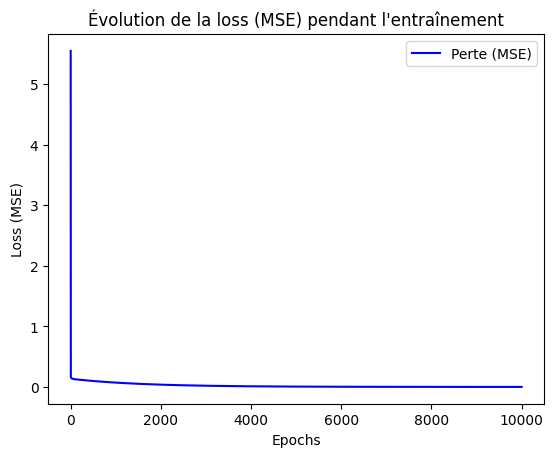

In [71]:
model = create_MLP([1, 5, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 10_000, 0.1, False)

plot_losses(losses)

In [72]:
predictions = predict_MLP(model, X, 1, False)
predictions

array([[2.00978373],
       [2.98230904],
       [2.50686105]])

### Linear Simple 3D :

/tmp/ipykernel_1119755/1181262459.py:15: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


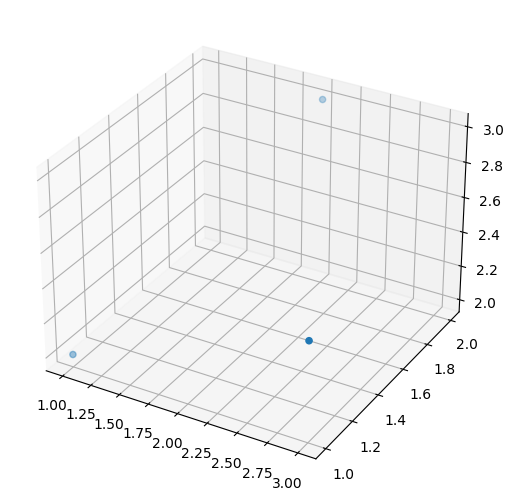

<Figure size 640x480 with 0 Axes>

In [73]:
from mpl_toolkits.mplot3d import Axes3D

X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

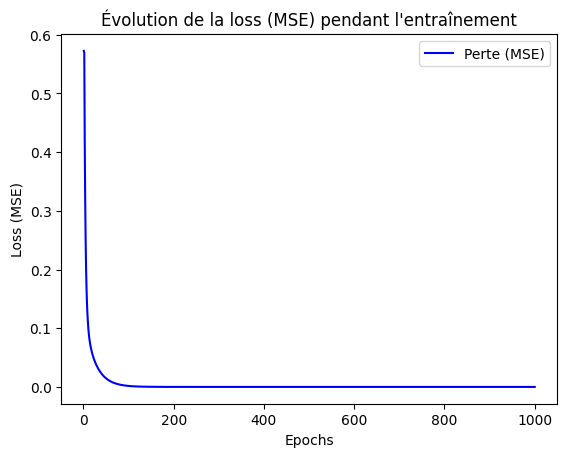

In [75]:
model = create_MLP([2, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 1000, 0.1, False)

plot_losses(losses)

In [76]:
predictions = predict_MLP(model, X, 1, False)
predictions

array([[2. ],
       [3. ],
       [2.5]])

### Linear Tricky 3D :

/tmp/ipykernel_1119755/2155744248.py:13: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


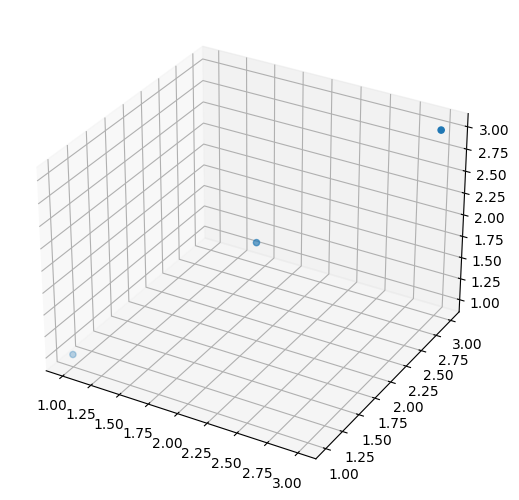

<Figure size 640x480 with 0 Axes>

In [77]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

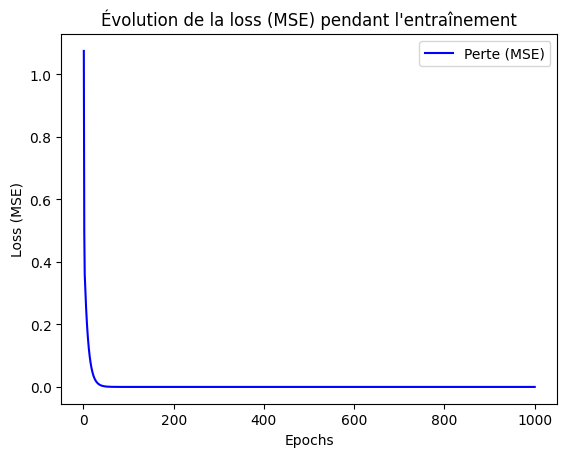

In [78]:
model = create_MLP([2, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 1000, 0.1, False)

plot_losses(losses)

In [79]:
predictions = predict_MLP(model, X, 1, False)
predictions

array([[1.],
       [2.],
       [3.]])

### Non Linear Simple 3D :

/tmp/ipykernel_940760/2655326972.py:15: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


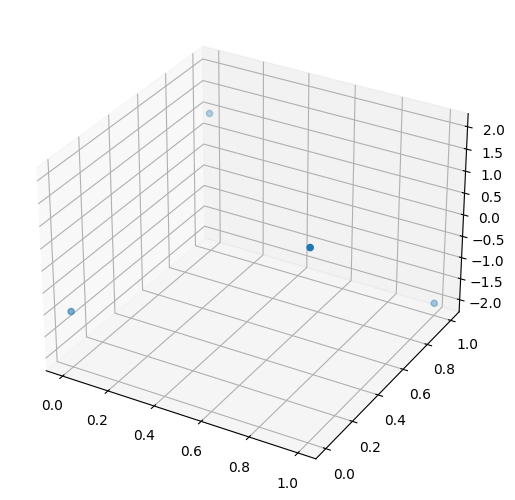

<Figure size 640x480 with 0 Axes>

In [29]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

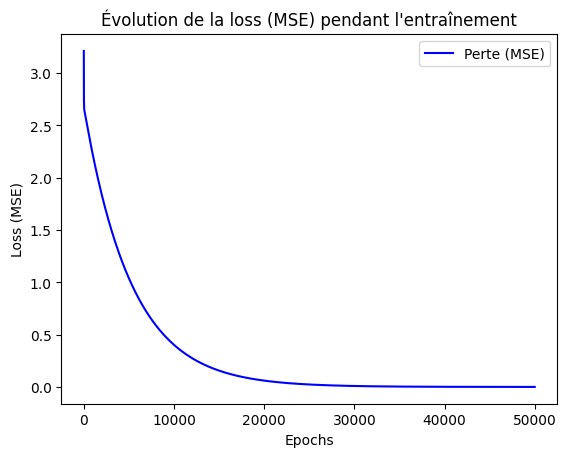

In [30]:
model = create_MLP([2, 3, 1])

losses = train_MLP(model, X, Y.reshape(-1, 1), 50_000, 0.1, False)

plot_losses(losses)

In [31]:
predictions = predict_MLP(model, X, 1, False)
predictions

array([[ 1.98469846],
       [ 0.98544892],
       [-1.98880241],
       [-0.98781324]])

### Test sur des images

In [34]:
import cv2
import os
import numpy as np

def load_emotion_data(emotion, n):
    """
    Charge les n premières images d'une émotion spécifiée depuis un dossier.
    
    Args:
        emotion (str): Nom de l'émotion (nom du dossier).
        n (int): Nombre d'images à charger.
    
    Returns:
        tuple: Un tuple contenant un tableau numpy d'images et une liste des étiquettes.
    """
    # Chemin vers le dossier contenant les images
    folder_path = f"../dataset/{emotion}/getty"
    
    # Liste pour stocker les tableaux d'images et les étiquettes
    images = []
    labels = []
    
    # Compteur pour suivre le nombre d'images chargées
    count = 0
    
    # Parcourir le dossier et charger chaque image
    for filename in os.listdir(folder_path):
        # Vérifier si le fichier est une image (vous pouvez ajouter d'autres extensions d'images si nécessaire)
        if filename.endswith(".png") or filename.endswith(".jpg"):
            # Chemin complet du fichier
            file_path = os.path.join(folder_path, filename)
            # Charger l'image en tant que tableau de pixels
            image = cv2.imread(file_path)

            image = cv2.resize(image, (28, 28))
            
            # Ajouter l'image à la liste
            images.append(image)
            labels.append(emotion)
            count += 1
            # Vérifier si nous avons atteint le nombre d'images souhaité
            if count == n:
                break
    
    # Convertir la liste d'images en un tableau numpy
    images_array = np.array(images)
    
    # Afficher la forme de l'array numpy résultant
    print("Forme de l'array d'images :", images_array.shape)

    return images_array, labels

def load_data(n):
    (happy_data, happy_label) = load_emotion_data("happy",n)
    (neutral_data, neutral_label) = load_emotion_data("neutral",n)
    (sad_data, sad_label) = load_emotion_data("sad",n)
    X = np.concatenate((happy_data, neutral_data, sad_data), axis=0)
    y = np.concatenate((happy_label, neutral_label, sad_label), axis=0)
    
    # perm = np.random.permutation(len(X))
    # X = X[perm]
    # y = y[perm]

    return (X,y)

def show_images(images_array, n):
    """
    Affiche les n premières images de images_array.
    
    Args:
        images_array (np.ndarray): Tableau numpy contenant les images.
        n (int): Nombre d'images à afficher.
    """
    # Vérifier que le nombre d'images demandé est inférieur ou égal au nombre total d'images
    n = min(n, len(images_array))
    
    # Créer une figure et des sous-plots pour afficher les images
    fig, axes = plt.subplots(1, n, figsize=(15, 15))
    
    # Afficher chaque image
    for i in range(n):
        # Lire l'image depuis le tableau d'images
        image = images_array[i]
        # Afficher l'image sur le subplot correspondant
        axes[i].imshow(image)
        axes[i].axis('off')  # Désactiver les axes
        
    plt.show()

Forme de l'array d'images : (10, 28, 28, 3)
Forme de l'array d'images : (10, 28, 28, 3)
Forme de l'array d'images : (10, 28, 28, 3)


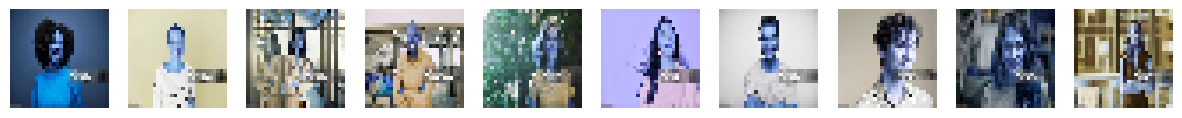

array(['happy', 'happy', 'happy', 'happy', 'happy', 'happy', 'happy',
       'happy', 'happy', 'happy'], dtype='<U7')

In [35]:
X,y = load_data(10)
show_images(X,10)
y[:10]

In [38]:
from sklearn.preprocessing import OneHotEncoder

# Load the data
X,y = load_data(10)
n_samples = len(X)

# Réorganiser les données X et y selon la permutation
# perm = np.random.permutation(len(X))
# X = X[perm]
# y = y[perm]

nlp = np.array([2352, 32, 3],np.int32)
c_nlp = np.ctypeslib.as_ctypes(nlp)
model = my_lib.create_MyMLP(c_nlp, len(nlp))


X_chunk = X.shape[1] * X.shape[2] * X.shape[3]
X_transformed = np.array(X, np.float64).flatten()/255

# Créer un encodeur OneHotEncoder
encoder = OneHotEncoder(sparse=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))
y_chunk = len(y_encoded[0])
y_encoded = y_encoded.flatten()

c_X = np.ctypeslib.as_ctypes(X_transformed)
c_y = np.ctypeslib.as_ctypes(y_encoded)

epochs = 100

p_losses = my_lib.train_MyMLP(model,
                    
                   c_X,
                   X_chunk, 
                   
                   c_y,
                   y_chunk, 
                   
                   n_samples,
                   0.1,
                   epochs,
                   True)

p_predictions = my_lib.predict_MyMLP(model,
                     True,
                     c_X,
                     X_chunk,
                     n_samples)

flatten_pred = np.ctypeslib.as_array(p_predictions, (y_chunk * n_samples,)).reshape(n_samples, y_chunk)
losses = np.ctypeslib.as_array(p_losses, (epochs,))

Forme de l'array d'images : (10, 28, 28, 3)
Forme de l'array d'images : (10, 28, 28, 3)
Forme de l'array d'images : (10, 28, 28, 3)


/home/bao/.local/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [39]:
pred = [np.argmax(sample) for sample in flatten_pred]
print(pred)
print(y)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0]
['happy' 'happy' 'happy' 'happy' 'happy' 'happy' 'happy' 'happy' 'happy'
 'happy' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral'
 'neutral' 'neutral' 'neutral' 'neutral' 'sad' 'sad' 'sad' 'sad' 'sad'
 'sad' 'sad' 'sad' 'sad' 'sad']


In [30]:
predictions = predict_MLP(model, X, 3, False)
predictions

array([[ 1.46161336e+01,  7.62485040e+00, -3.84183545e+00],
       [ 1.34758315e+01,  1.49194713e+00, -1.09785520e+01],
       [ 2.02458165e+01, -5.22471185e+00, -1.24304007e+01],
       [ 1.70843629e+01, -2.94210257e+00, -1.40936575e+01],
       [-2.30819336e+00,  7.72238754e+00, -1.46116289e+01],
       [ 1.44389592e+01,  4.41923775e-01, -1.39643701e+01],
       [ 1.79834466e+01, -2.43234015e+00, -1.05488120e+01],
       [-7.31114533e-01,  8.36968517e+00, -1.07844297e+01],
       [ 1.44247249e+01,  4.33853241e-01, -1.40204923e+01],
       [ 1.09374210e+01,  2.12169636e+00, -1.38702654e+01],
       [-2.21601895e+00,  8.92315841e+00, -1.02560304e+01],
       [ 1.44246916e+01,  4.33792470e-01, -1.40203070e+01],
       [ 1.79607126e-02,  1.84857712e+00, -1.51083359e+01],
       [ 3.43810163e-01,  2.44334337e+00, -1.69218198e+01],
       [ 1.09374210e+01,  2.12169636e+00, -1.38702654e+01],
       [ 3.17956023e+00, -4.22418750e-01, -1.34730262e+01],
       [ 1.09197692e+01,  2.70787079e+00

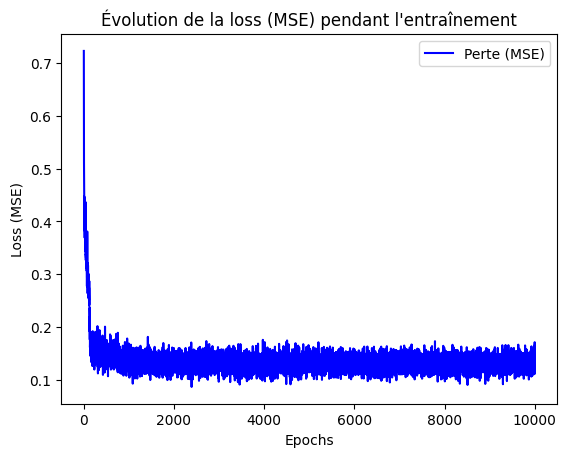

In [31]:
plot_losses(losses)